# Reconstruction de l'environnement sonar à partir de 2 capteurs

Ce notebook entraîne et compare deux architectures :
- **UNet** : architecture encoder-decoder avec skip connections

**Données** : fichier `.mat` contenant :
- `data` : matrice de signaux (9 × 2001)
- `map` : carte 2D de l'environnement réel

**Pipeline** :
1. Chargement & extraction des 2 capteurs
2. Normalisation par capteur
3. Augmentation de données
4. Entraînement avec BCE+Dice Loss pondérée
5. Comparaison SimpleCNN vs U-Net
6. Diagnostic complet

## 1) Imports

In [2]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import train_test_split

import random
import copy
import os

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(f'Device utilisé : {device}')


Device utilisé : cpu


## 2) Chargement des données

On extrait les **2 capteurs choisis** parmi les 9 disponibles et on tronque
la partie aller du signal (avant la colonne 1200).

In [3]:
# ── Chemins des 3 fichiers de données ────────────────────────────────────
DATA_FILES = [
    ('Rond',              '9capteurs_100samples_rond.mat'),
    ('Lignes',            '9capteurs_300sample_lines.mat'),
    ('Multi-triangles',   '9capteurs_300samples_2_triangle.mat'),
]
SIGNAL_START = 1200   # on ignore la partie aller (émission)
SIGNAL_LEN   = 801    # longueur cible après troncature (tronque ou padde)
MAP_SIZE     = (150, 150)

# Structure de chaque expérience dans results :
#   sub[0] : signaux bruts        (9, 2001)
#   sub[1] : reconstruction phys. (150, 150)
#   sub[2] : carte cible binaire  (150, 150)

def fix_signal(sig, start, target_len):
    sig = np.array(sig, dtype=np.float32)
    sig = sig[:, start:]                          # partie retour
    L = sig.shape[1]
    if L >= target_len:
        return sig[:, :target_len]                # tronque
    else:
        pad = np.zeros((sig.shape[0], target_len - L), dtype=np.float32)
        return np.concatenate([sig, pad], axis=1) # padde avec des zéros

def fix_map(m, target_size):
    m = np.array(m, dtype=np.float32)
    if m.shape == target_size:
        return m
    # Redimensionnement via torch si taille différente
    import torch, torch.nn.functional as F
    t = torch.tensor(m).unsqueeze(0).unsqueeze(0)
    t = F.interpolate(t, size=target_size, mode='nearest')
    return t.squeeze().numpy()

list_signals = []
list_bf      = []
list_outputs = []
list_types   = []
shape_issues = []

for class_idx, (class_name, fpath) in enumerate(DATA_FILES):

    raw_data = loadmat(fpath)['results'].squeeze()
    n_before = len(list_signals)
    sig_shapes = set()

    for exp in raw_data:
        signals, bf_img, target = exp[0], exp[1], exp[2]
        sig = fix_signal(signals, SIGNAL_START, SIGNAL_LEN)  # (9, 801)
        if sig.shape != (9, 801):
            continue
        bf  = fix_map(bf_img, MAP_SIZE)                      # (150, 150)
        tgt = fix_map(target,  MAP_SIZE)                     # (150, 150)

        sig_shapes.add(sig.shape)
        list_signals.append(sig)
        list_bf.append(bf)
        list_outputs.append(tgt)
        list_types.append(class_idx)

    n_loaded = len(list_signals) - n_before
    print(f'  {class_name:<20} : {n_loaded} échantillons  '
          f'(shapes signal observées : {sig_shapes})')

X_raw      = np.array(list_signals, dtype=np.float32)  # (N, 9, 801)
X_bf       = np.array(list_bf,      dtype=np.float32)  # (N, 150, 150)
y_raw      = np.array(list_outputs, dtype=np.float32)  # (N, 150, 150)
shape_type = np.array(list_types,   dtype=np.int64)    # (N,)
CLASS_NAMES = [name for name, _ in DATA_FILES]

print(f'\nTotal : {X_raw.shape[0]} échantillons')
print(f'X_raw shape  : {X_raw.shape}')
print(f'X_bf  shape  : {X_bf.shape}')
print(f'y_raw shape  : {y_raw.shape}')
ratio_pos = y_raw.mean()
print(f'Ratio pixels positifs : {ratio_pos:.4f} ({ratio_pos*100:.2f}%)')


  Rond                 : 100 échantillons  (shapes signal observées : {(9, 801)})
  Lignes               : 380 échantillons  (shapes signal observées : {(9, 801)})
  Multi-triangles      : 380 échantillons  (shapes signal observées : {(9, 801)})

Total : 860 échantillons
X_raw shape  : (860, 9, 801)
X_bf  shape  : (860, 150, 150)
y_raw shape  : (860, 150, 150)
Ratio pixels positifs : 0.0021 (0.21%)


## 3) Visualisation des données brutes

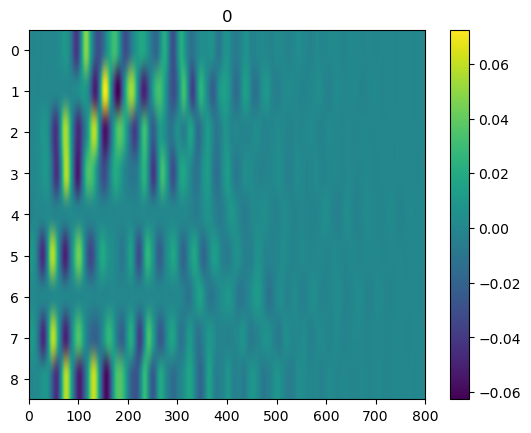

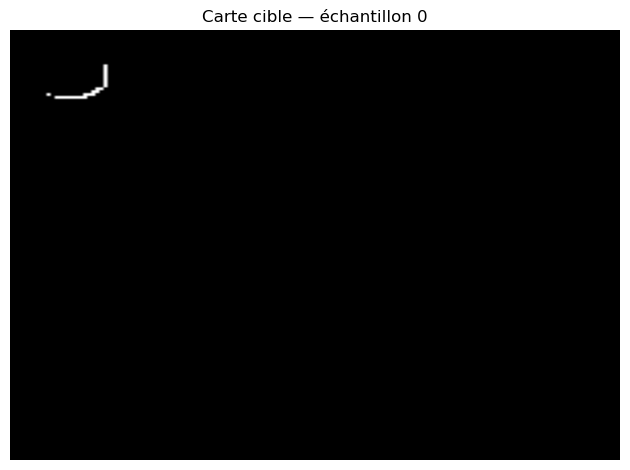

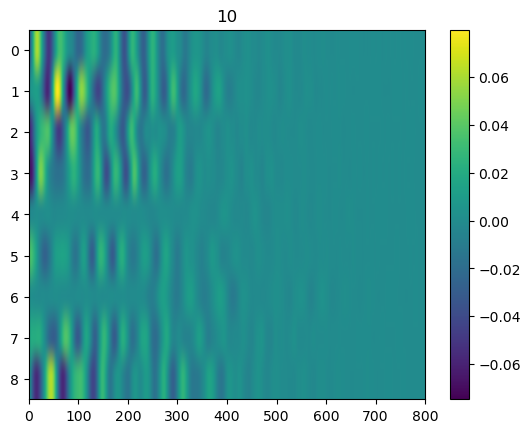

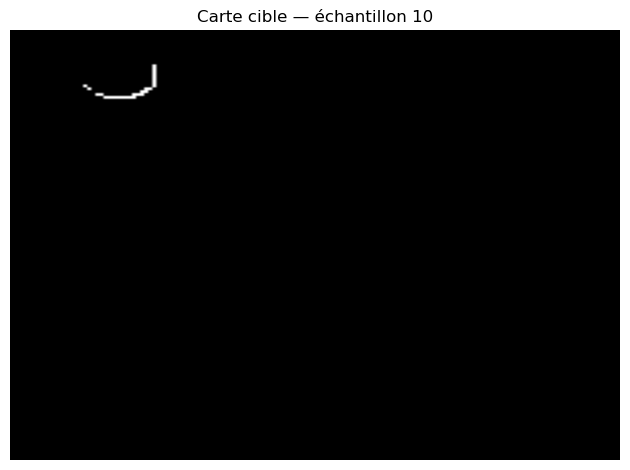

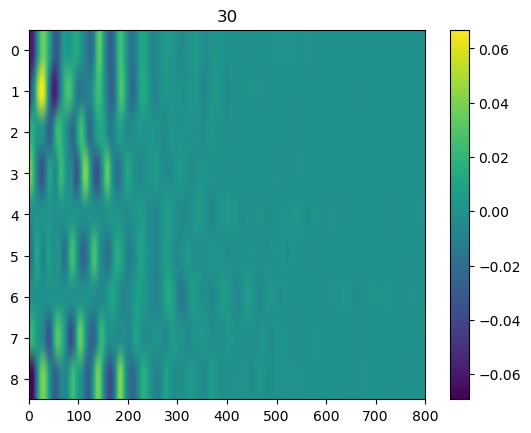

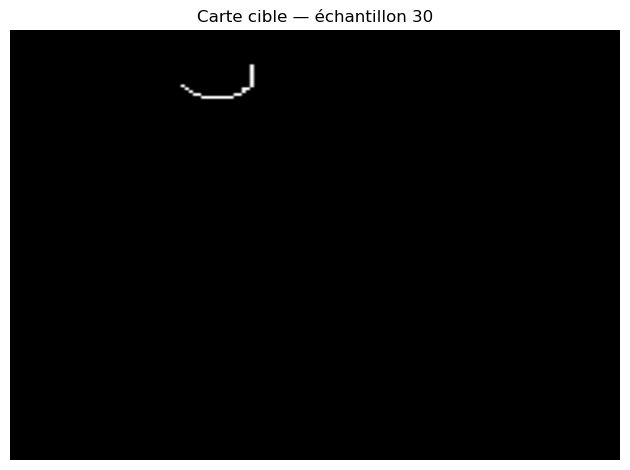

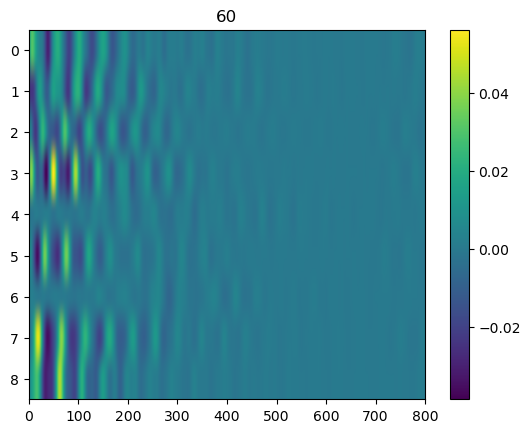

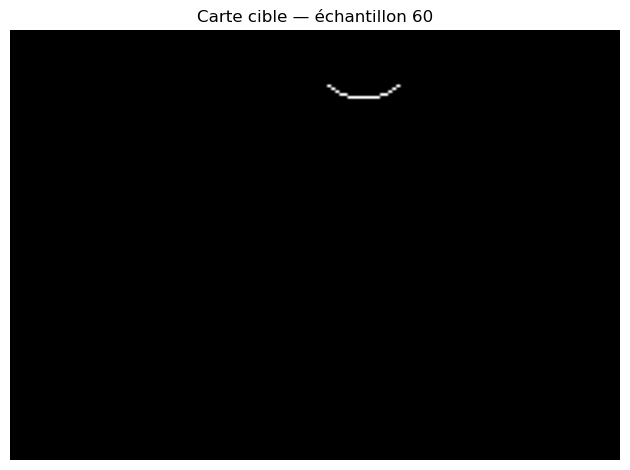

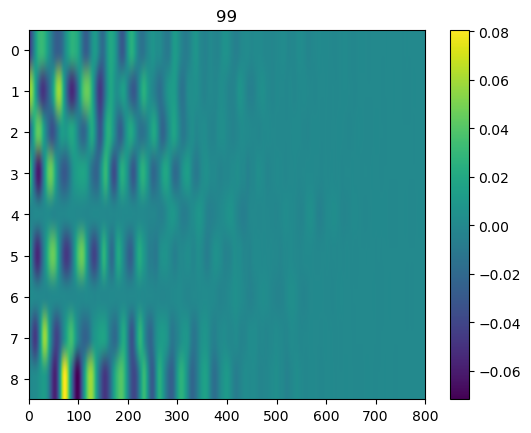

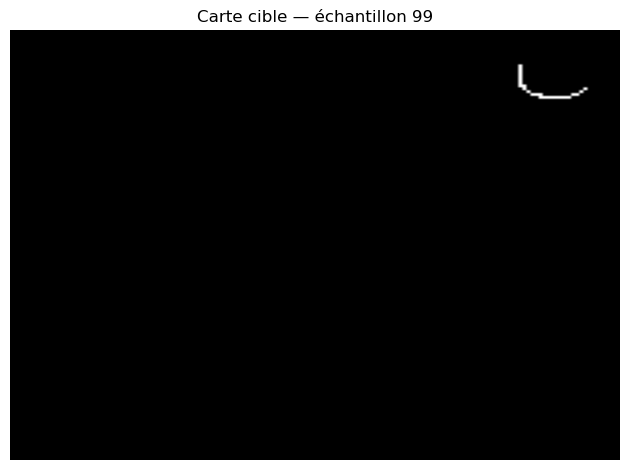

In [4]:
indices = [0, 10, 30, 60, 99]
for idx in indices:

    plt.imshow(X_raw[idx], aspect='auto')
    plt.colorbar()
    plt.title(str(idx))
    plt.show()

    plt.imshow(y_raw[idx], cmap='gray', aspect='auto')
    plt.title(f"Carte cible — échantillon {idx}")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## 4) Normalisation par capteur

On normalise **séparément** chaque capteur (moyenne et écart-type calculés sur le train set).
Cela évite qu'un capteur plus fort domine l'autre.

In [5]:
# Normalisation des signaux par capteur
mean_per_ch = X_raw.mean(axis=(0, 2), keepdims=True)   # (1, 9, 1)
std_per_ch  = X_raw.std(axis=(0, 2),  keepdims=True)   # (1, 9, 1)
std_per_ch[std_per_ch == 0] = 1.0
X_norm = (X_raw - mean_per_ch) / std_per_ch

# Normalisation de la reconstruction physique (min-max vers [0,1])
bf_min = X_bf.min(axis=(1, 2), keepdims=True)
bf_max = X_bf.max(axis=(1, 2), keepdims=True)
bf_range = np.where(bf_max - bf_min == 0, 1.0, bf_max - bf_min)
X_bf_norm = (X_bf - bf_min) / bf_range   # (N, 150, 150) dans [0, 1]

print(f'Signaux normalisés  — mean: {X_norm.mean():.4f}, std: {X_norm.std():.4f}')
print(f'BF normalisé        — min:  {X_bf_norm.min():.4f}, max: {X_bf_norm.max():.4f}')


Signaux normalisés  — mean: -0.0000, std: 1.0000
BF normalisé        — min:  0.0000, max: 1.0000


## 5) Dataset avec augmentation de données

Trois augmentations appliquées aléatoirement pendant l'entraînement :
- **Décalage horizontal** : on décale signal et carte dans la même direction
- **Bruit gaussien** : léger bruit sur le signal d'entrée
- **Flip horizontal** : symétrie gauche-droite cohérente signal/carte

In [6]:
class SonarDataset(Dataset):
    """
    Dataset 9 capteurs avec augmentation optionnelle.

    X    : (N, 9, 801)    — signaux normalisés
    X_bf : (N, 150, 150)  — reconstruction physique normalisée (optionnel)
    y    : (N, 150, 150)  — cartes cibles binaires
    """
    def __init__(self, X, y, X_bf=None, augment=False):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32).unsqueeze(1)
        self.X_bf = torch.tensor(X_bf, dtype=torch.float32).unsqueeze(1) if X_bf is not None else None
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x    = self.X[idx].clone()    # (9, 801)
        y    = self.y[idx].clone()    # (1, 150, 150)
        x_bf = self.X_bf[idx].clone() if self.X_bf is not None else None  # (1, 150, 150)

        if self.augment:
            # 1) Bruit gaussien
            if random.random() < 0.5:
                x = x + torch.randn_like(x) * 0.05

            # 2) Flip horizontal (signal + BF + carte)
            if random.random() < 0.5:
                x = torch.flip(x, dims=[-1])
                y = torch.flip(y, dims=[-1])
                if x_bf is not None:
                    x_bf = torch.flip(x_bf, dims=[-1])

            # 3) Décalage horizontal
            if random.random() < 0.5:
                shift = random.randint(-20, 20)
                x = torch.roll(x, shift, dims=-1)
                map_shift = int(shift * 150 / 801)
                y = torch.roll(y, map_shift, dims=-1)
                if x_bf is not None:
                    x_bf = torch.roll(x_bf, map_shift, dims=-1)

            # 4) Scaling d'amplitude
            if random.random() < 0.5:
                x = x * random.uniform(0.8, 1.2)

            # 5) Écho artificiel
            if random.random() < 0.3:
                delay = random.randint(5, 20)
                x = x + torch.roll(x, delay, dims=-1) * 0.15

        if x_bf is not None:
            return x, x_bf, y
        return x, y


## 6) Split stratifié par type de forme

On s'assure que chaque split (train/val/test) contient la même proportion
de chaque type de forme, évitant ainsi un biais d'évaluation.


In [7]:
N = len(X_norm)

idx = np.arange(N)
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.20, stratify=shape_type, random_state=SEED
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15/0.80,
    stratify=shape_type[idx_trainval], random_state=SEED
)

print(f'Train : {len(idx_train)} | Val : {len(idx_val)} | Test : {len(idx_test)}')
print('Distribution par classe :')
for split_name, split_idx in [('Train', idx_train), ('Val', idx_val), ('Test', idx_test)]:
    counts = [f'{name}: {(shape_type[split_idx]==c).sum()}'
              for c, name in enumerate(CLASS_NAMES)]
    print(f'  {split_name}: {" | ".join(counts)}')

# Datasets avec reconstruction physique (pour Y-Net)
train_set = SonarDataset(X_norm[idx_train], y_raw[idx_train],
                          X_bf=X_bf_norm[idx_train], augment=True)
val_set   = SonarDataset(X_norm[idx_val],   y_raw[idx_val],
                          X_bf=X_bf_norm[idx_val],   augment=False)
test_set  = SonarDataset(X_norm[idx_test],  y_raw[idx_test],
                          X_bf=X_bf_norm[idx_test],  augment=False)

# Datasets par classe pour l'évaluation
test_sets_by_class = {}
for c, name in enumerate(CLASS_NAMES):
    mask = shape_type[idx_test] == c
    test_sets_by_class[name] = SonarDataset(
        X_norm[idx_test[mask]], y_raw[idx_test[mask]],
        X_bf=X_bf_norm[idx_test[mask]], augment=False
    )
    print(f'Test {name} : {mask.sum()} échantillons')

BATCH_SIZE = 8

# Loaders pour SimpleCNN / UNet1D (sans BF — retournent (x, y))
# On crée des datasets sans X_bf pour ces modèles
train_set_base = SonarDataset(X_norm[idx_train], y_raw[idx_train], augment=True)
val_set_base   = SonarDataset(X_norm[idx_val],   y_raw[idx_val],   augment=False)
test_set_base  = SonarDataset(X_norm[idx_test],  y_raw[idx_test],  augment=False)

train_loader = DataLoader(train_set_base, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_set_base,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set_base,  batch_size=BATCH_SIZE, shuffle=False)

test_loaders_by_class = {
    name: DataLoader(
        SonarDataset(X_norm[idx_test[shape_type[idx_test]==c]],
                     y_raw[idx_test[shape_type[idx_test]==c]], augment=False),
        batch_size=BATCH_SIZE, shuffle=False
    )
    for c, name in enumerate(CLASS_NAMES)
}
print('Loaders créés.')


Train : 559 | Val : 129 | Test : 172
Distribution par classe :
  Train: Rond: 65 | Lignes: 247 | Multi-triangles: 247
  Val: Rond: 15 | Lignes: 57 | Multi-triangles: 57
  Test: Rond: 20 | Lignes: 76 | Multi-triangles: 76
Test Rond : 20 échantillons
Test Lignes : 76 échantillons
Test Multi-triangles : 76 échantillons
Loaders créés.


## 7) Loss : BCE pondérée + Dice

Le fort déséquilibre de classes (peu de pixels à 1) nécessite une pondération.
- `pos_weight` amplifie la pénalité sur les faux négatifs
- La Dice Loss force le modèle à bien recouvrir la **forme** de l'objet

> **Note** : on utilise `BCEWithLogitsLoss` (plus stable numériquement).
> Les architectures ne doivent donc **pas** avoir de `Sigmoid()` en sortie.

In [8]:
def compute_pos_weight(y_array, device):
    """Calcule automatiquement le pos_weight depuis les données."""
    ratio = y_array.mean()
    if ratio == 0:
        return torch.tensor([50.0], device=device)
    pw = (1.0 - ratio) / ratio
    # On plafonne pour éviter des valeurs extrêmes
    pw = float(np.clip(pw, 5.0, 200.0))
    print(f"pos_weight calculé : {pw:.1f}  (ratio positifs = {ratio*100:.2f}%)")
    return torch.tensor([pw], device=device)


class BCEDiceLoss(nn.Module):
    """
    Combinaison BCE pondérée + Dice Loss.
    Les modèles doivent retourner des logits (pas de Sigmoid en sortie).
    """
    def __init__(self, pos_weight, bce_weight=0.4):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        # Dice sur les probabilités (après sigmoid)
        probs = torch.sigmoid(logits)
        smooth = 1e-6
        p = probs.reshape(probs.size(0), -1)
        t = targets.reshape(targets.size(0), -1)
        intersection = (p * t).sum(dim=1)
        dice_loss = 1 - (2 * intersection + smooth) / (p.sum(dim=1) + t.sum(dim=1) + smooth)
        dice_loss = dice_loss.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


pos_weight = compute_pos_weight(y_raw, device)

pos_weight calculé : 200.0  (ratio positifs = 0.21%)


## 8) Architectures

### 8a) SimpleCNN — adapté 2 capteurs

Architecture légère conçue pour l'entrée `(2, 801)` :
- Convolutions 1D sur chaque capteur → extraction de features temporelles
- Fusion des deux capteurs
- Décodeur 2D vers la carte `(15, 150)`

In [9]:
class SimpleCNN(nn.Module):
    """
    CNN adapté à l'entrée 2 capteurs (2, 801) -> carte (1, 15, 150).
    Retourne des logits (pas de Sigmoid).
    """
    def __init__(self):
        super().__init__()

        # ── Encodeur 1D (opère sur les signaux temporels) ────────────────────
        self.encoder_1d = nn.Sequential(
            nn.Conv1d(2, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),           # -> (16, 400)

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),           # -> (32, 200)

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),           # -> (64, 100)

            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),           # -> (64, 50)
        )

        # ── Transition 1D -> 2D ───────────────────────────────────────────────
        # On reshape (64, 50) en (64, 5, 10) pour alimenter un décodeur 2D
        self.reshape_h = 5
        self.reshape_w = 10

        # ── Décodeur 2D vers (1, 15, 150) ────────────────────────────────────
        self.decoder_2d = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),   # -> (64, 10, 20)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # -> (32, 20, 40)
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),

            nn.Conv2d(16, 1, kernel_size=1),   # logits
        )

    def forward(self, x):
        # x : (B, 2, 801)
        feat = self.encoder_1d(x)                              # (B, 64, 50)
        B, C, L = feat.shape
        feat = feat.reshape(B, C, self.reshape_h, self.reshape_w)  # (B, 64, 5, 10)
        out = self.decoder_2d(feat)                            # (B, 1, 20, 40)
        # Interpolation bilinéaire vers la taille cible exacte
        out = F.interpolate(out, size=(15, 150), mode='bilinear', align_corners=False)
        return out   # logits (B, 1, 15, 150)

### 8b) U-Net adapté 2 capteurs

U-Net avec skip connections, adapté à l'entrée `(2, 801)` :
- L'entrée reste 2D `(2, 801)` — on la traite comme une image de hauteur 2
- Chaque bloc inclut BatchNorm pour stabiliser l'entraînement
- `F.interpolate` en sortie pour obtenir exactement `(15, 150)` sans crop brutal

In [10]:
class DoubleConv(nn.Module):
    """Deux convolutions 2D + BatchNorm + ReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class UNet2Ch(nn.Module):
    """
    U-Net adapté à l'entrée (2, 801) traitée comme image 2D (H=2, W=801).
    Sortie : logits (1, 15, 150) — pas de Sigmoid.
    """
    def __init__(self):
        super().__init__()

        # ── Encodeur ─────────────────────────────────────────────────────────
        # On unsqueeze l'entrée pour avoir (B, 1, 9, 801)
        self.enc1 = DoubleConv(1,  32)   # (1,9,801)  -> (32,9,801)
        self.enc2 = DoubleConv(32, 64)   # -> (64,1,400) après pool
        self.enc3 = DoubleConv(64, 128)  # -> (128,1,200) après pool
        self.pool = nn.MaxPool2d(kernel_size=(1, 2))  # on ne réduit que la largeur

        # ── Goulot ───────────────────────────────────────────────────────────
        self.bottleneck = DoubleConv(128, 256)  # (256,1,100)

        # ── Décodeur avec skip connections ───────────────────────────────────
        self.up3  = nn.ConvTranspose2d(256, 128, kernel_size=(1, 2), stride=(1, 2))
        self.dec3 = DoubleConv(256, 128)

        self.up2  = nn.ConvTranspose2d(128, 64, kernel_size=(1, 2), stride=(1, 2))
        self.dec2 = DoubleConv(128, 64)

        self.up1  = nn.ConvTranspose2d(64, 32, kernel_size=(1, 2), stride=(1, 2))
        self.dec1 = DoubleConv(64, 32)

        self.final = nn.Conv2d(32, 1, kernel_size=1)   # logits

    @staticmethod
    def _align(skip, target):
        """Recadre skip à la taille de target (H et W)."""
        return skip[:, :, :target.shape[2], :target.shape[3]]

    def forward(self, x):
        # x : (B, 2, 801) — on le traite comme image (B, 1, 2, 801)
        x = x.unsqueeze(1)                                    # (B, 1, 2, 801)

        s1 = self.enc1(x)                                     # (B, 32, 2, 801)
        s2 = self.enc2(self.pool(s1))                         # (B, 64, 2, 400)
        s3 = self.enc3(self.pool(s2))                         # (B, 128, 2, 200)

        b  = self.bottleneck(self.pool(s3))                   # (B, 256, 2, 100)

        d3 = self.up3(b)                                      # (B, 128, 2, 200)
        d3 = self.dec3(torch.cat([d3, self._align(s3, d3)], dim=1))

        d2 = self.up2(d3)                                     # (B, 64, 2, 400)
        d2 = self.dec2(torch.cat([d2, self._align(s2, d2)], dim=1))

        d1 = self.up1(d2)                                     # (B, 32, 2, 801)
        d1 = self.dec1(torch.cat([d1, self._align(s1, d1)], dim=1))

        out = self.final(d1)                                  # (B, 1, 2, 801)

        # Interpolation vers la taille cible (15, 150)
        out = F.interpolate(out, size=(150, 150), mode='bilinear', align_corners=False)
        return out   # logits (B, 1, 15, 150)


# ── Vérification rapide des shapes ───────────────────────────────────────────
with torch.no_grad():
    dummy = torch.zeros(2, 9, 801)
    print("UNet2Ch  output shape  :", UNet2Ch()(dummy).shape)

UNet2Ch  output shape  : torch.Size([2, 1, 150, 150])


## 9) Fonctions utilitaires : métriques & visualisation

In [11]:
def compute_metrics(logits_np, targets_np, threshold=0.5):
    """Calcule Accuracy, Précision, Rappel, F1, IoU sur des arrays numpy."""
    preds = (logits_np >= threshold).astype(float)
    TP = ((preds == 1) & (targets_np == 1)).sum()
    FP = ((preds == 1) & (targets_np == 0)).sum()
    FN = ((preds == 0) & (targets_np == 1)).sum()
    TN = ((preds == 0) & (targets_np == 0)).sum()
    eps = 1e-8
    return {
        "Accuracy"  : (TP + TN) / (TP + FP + FN + TN + eps),
        "Précision" : TP / (TP + FP + eps),
        "Rappel"    : TP / (TP + FN + eps),
        "F1"        : 2*TP / (2*TP + FP + FN + eps),
        "IoU"       : TP / (TP + FP + FN + eps),
    }


def collect_preds(model, loader, device):
    """Collecte toutes les prédictions (probabilités) et targets sur un loader."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs.flatten())
            all_targets.append(targets.numpy().flatten())
    return np.concatenate(all_probs), np.concatenate(all_targets)


def show_predictions(model, loader, device, num_samples=8, threshold=0.5, title=""):
    """Affiche vérité terrain vs prédiction pour num_samples exemples."""
    model.eval()
    shown = 0
    fig, axes_list = plt.subplots(num_samples, 2,
                                  figsize=(8, num_samples * 1.4))
    if num_samples == 1:
        axes_list = [axes_list]

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            probs  = torch.sigmoid(model(inputs)).cpu().numpy()
            for i in range(inputs.size(0)):
                if shown >= num_samples:
                    break
                ax_gt, ax_pred = axes_list[shown]
                ax_gt.imshow(targets[i].squeeze(), cmap='gray', vmin=0, vmax=1)
                ax_gt.set_title("Vérité terrain", fontsize=8)
                ax_gt.axis('off')
                ax_pred.imshow(probs[i].squeeze(), cmap='gray', vmin=0, vmax=1)
                ax_pred.set_title(f"Prédiction {title}", fontsize=8)
                ax_pred.axis('off')
                shown += 1
            if shown >= num_samples:
                break
    plt.tight_layout()
    plt.show()


def show_diagnostic(model, loader, device, num_samples=5, threshold=0.5, title=""):
    """Affiche GT / probabilité / binarisé / carte d'erreurs (rouge=FP, bleu=FN, vert=TP)."""
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            probs  = torch.sigmoid(model(inputs)).cpu().numpy()
            for i in range(inputs.size(0)):
                if shown >= num_samples:
                    return
                prob   = probs[i].squeeze()
                pred   = (prob >= threshold).astype(float)
                target = targets[i].squeeze().numpy()

                err = np.zeros((*target.shape, 3))
                err[(pred==1)&(target==1)] = [0, 1, 0]   # TP vert
                err[(pred==1)&(target==0)] = [1, 0, 0]   # FP rouge
                err[(pred==0)&(target==1)] = [0, 0, 1]   # FN bleu

                fig, axes = plt.subplots(1, 4, figsize=(16, 2.5))
                axes[0].imshow(target, cmap='gray', vmin=0, vmax=1)
                axes[0].set_title("Vérité terrain")
                axes[1].imshow(prob,   cmap='hot',  vmin=0, vmax=1)
                axes[1].set_title("Probabilité")
                axes[2].imshow(pred,   cmap='gray', vmin=0, vmax=1)
                axes[2].set_title(f"Préd. (seuil={threshold:.2f})")
                axes[3].imshow(err)
                axes[3].set_title("TP=vert / FP=rouge / FN=bleu")
                for ax in axes:
                    ax.axis('off')
                if title:
                    fig.suptitle(title, fontsize=10)
                plt.tight_layout()
                plt.show()
                shown += 1

## 10) Boucle d'entraînement

In [12]:
def train_model(model, train_loader, val_loader, criterion, device,
                epochs=300, lr=1e-3, patience=30, model_name="model"):
    """
    Entraîne un modèle avec early stopping et learning rate scheduler.
    Sauvegarde le meilleur modèle dans {model_name}.pth.
    Retourne le modèle avec les meilleurs poids et l'historique des pertes.
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # Réduction du LR si la val_loss stagne
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15
    )

    best_val_loss  = float('inf')
    best_weights   = copy.deepcopy(model.state_dict())
    no_improve     = 0
    history        = {'train': [], 'val': []}

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # ── Validation ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                val_loss += criterion(model(inputs), targets).item()
        val_loss /= len(val_loader)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"[{model_name}] Epoch {epoch+1:3d}/{epochs}  "
                  f"train={train_loss:.4f}  val={val_loss:.4f}")

        # ── Early stopping ──
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            torch.save(best_weights, f"{model_name}.pth")
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    print(f"\n[{model_name}] Meilleure val_loss : {best_val_loss:.4f}")
    return model, history

## 11) Entraînement des deux modèles

In [25]:
criterion = BCEDiceLoss(pos_weight=pos_weight, bce_weight=0.4)
print("\n" + "=" * 50)
print("Entraînement U-Net")
print("=" * 50)
model_unet, history_unet = train_model(
    UNet2Ch(), train_loader, val_loader, criterion, device,
    epochs=300, lr=5e-4, patience=40, model_name="model_unet_9capteurs"
)


Entraînement U-Net
[model_unet_9capteurs] Epoch   1/300  train=0.7597  val=0.7374
[model_unet_9capteurs] Epoch  20/300  train=0.6786  val=0.6879
[model_unet_9capteurs] Epoch  40/300  train=0.6563  val=0.6675
[model_unet_9capteurs] Epoch  60/300  train=0.6295  val=0.6719
[model_unet_9capteurs] Epoch  80/300  train=0.5770  val=0.7325
Early stopping à l'epoch 94

[model_unet_9capteurs] Meilleure val_loss : 0.6585


## 11b) Recharger les modèles sans réentraîner

Exécuter cette cellule si les fichiers `.pth` existent déjà.

In [17]:
def load_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Modèle chargé depuis {path}")
    return model

# Décommenter si besoin :
#model_cnn  = load_model(SimpleCNN, "model_simplecnn.pth", device)
model_unet = load_model(UNet2Ch,   "model_unet_9capteurs.pth",      device)

Modèle chargé depuis model_unet_9capteurs.pth


## 12) Courbes d'entraînement

NameError: name 'history_unet' is not defined

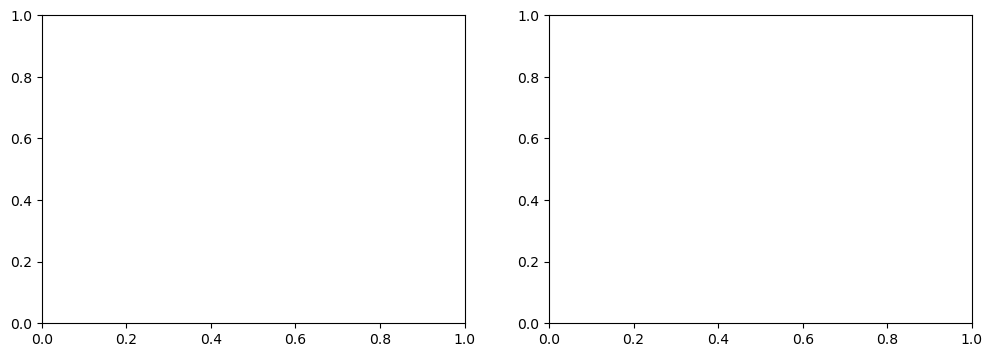

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, history, name in zip(axes, [ history_unet],
                             ["U-Net"]):
    ax.plot(history['train'], label='Train')
    ax.plot(history['val'],   label='Val')
    ax.set_title(f"Loss — {name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("BCE + Dice Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13) Recherche du seuil optimal et métriques


  U-Net  — seuil optimal : 0.80
  Accuracy    : 0.9730
  Précision   : 0.0529
  Rappel      : 0.6997
  F1          : 0.0984
  IoU         : 0.0517


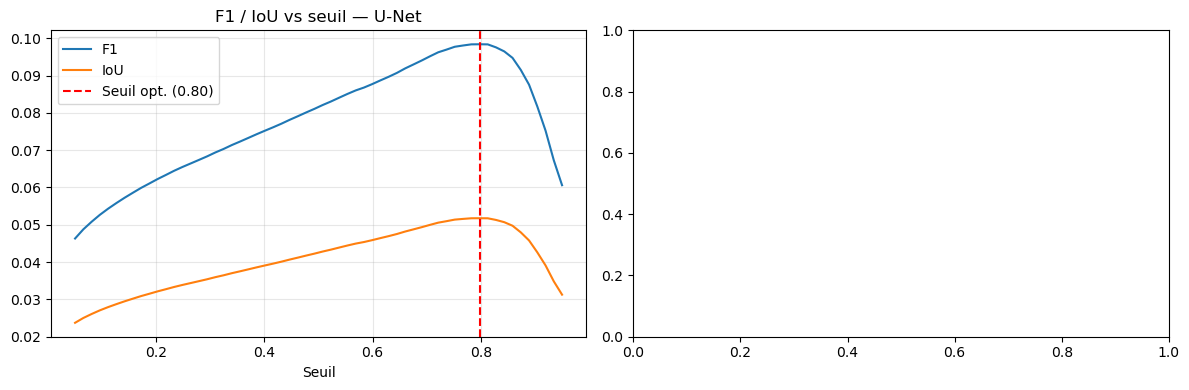

In [19]:
results = {}

for model, name in [(model_unet, "U-Net")]:
    probs, targets_np = collect_preds(model, test_loader, device)

    # Recherche du seuil optimal (max F1)
    thresholds = np.linspace(0.05, 0.95, 60)
    f1s  = [compute_metrics(probs, targets_np, t)["F1"]  for t in thresholds]
    ious = [compute_metrics(probs, targets_np, t)["IoU"] for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]

    metrics = compute_metrics(probs, targets_np, best_t)
    results[name] = {"metrics": metrics, "best_t": best_t,
                     "probs": probs, "targets": targets_np,
                     "thresholds": thresholds, "f1s": f1s, "ious": ious}

    print(f"\n{'='*40}")
    print(f"  {name}  — seuil optimal : {best_t:.2f}")
    print(f"{'='*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")

# ── Courbes F1 / IoU vs seuil ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["U-Net"]):
    r = results[name]
    ax.plot(r['thresholds'], r['f1s'],  label='F1')
    ax.plot(r['thresholds'], r['ious'], label='IoU')
    ax.axvline(r['best_t'], color='red', linestyle='--',
               label=f"Seuil opt. ({r['best_t']:.2f})")
    ax.set_title(f"F1 / IoU vs seuil — {name}")
    ax.set_xlabel("Seuil")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13b) Métriques par type de forme

On évalue séparément les performances sur chaque classe pour identifier
sur quelles formes le modèle peine le plus.



  Métriques par classe — U-Net
  Classe                   F1      IoU   Rappel  Précision
  --------------------------------------------------
  Rond                 0.0737   0.0383   0.6667     0.0390
  Lignes               0.0927   0.0486   0.7246     0.0495
  Multi-triangles      0.1077   0.0569   0.6842     0.0585


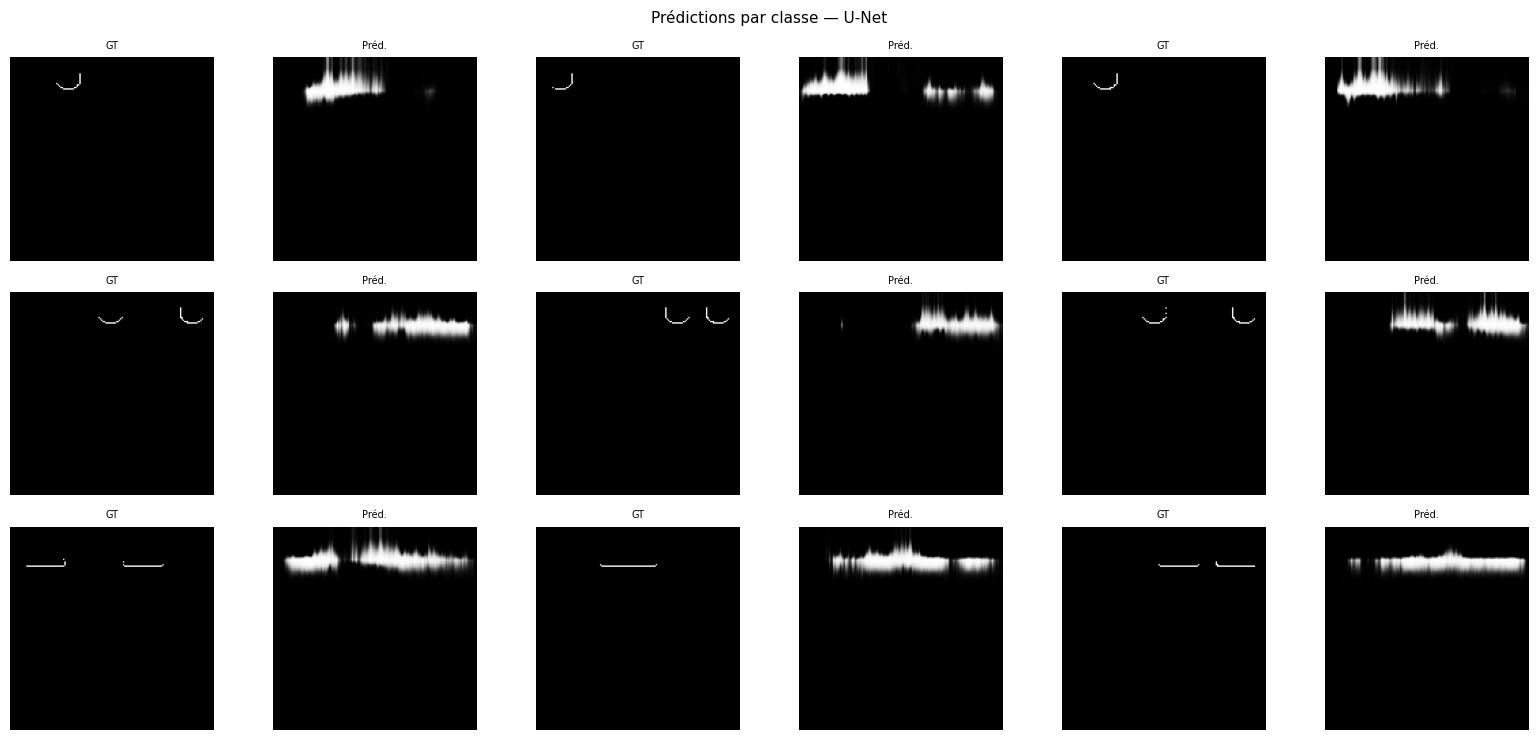

In [20]:
def evaluate_by_class(model, test_loaders_by_class, device, threshold=0.5, model_name=''):
    """Évalue les métriques séparément pour chaque type de forme."""
    model.eval()
    print(f'\n{'='*55}')
    print(f'  Métriques par classe — {model_name}')
    print(f'{'='*55}')
    print(f'  {"Classe":<18} {"F1":>8} {"IoU":>8} {"Rappel":>8} {"Précision":>10}')
    print(f'  {"-"*50}')

    all_results = {}
    for class_name, loader in test_loaders_by_class.items():
        probs, targets = collect_preds(model, loader, device)
        m = compute_metrics(probs, targets, threshold)
        all_results[class_name] = m
        print(f'  {class_name:<18} {m["F1"]:>8.4f} {m["IoU"]:>8.4f} '
              f'{m["Rappel"]:>8.4f} {m["Précision"]:>10.4f}')
    return all_results


def plot_by_class(model, test_loaders_by_class, device, threshold=0.5, model_name=''):
    """Affiche 3 exemples par classe avec GT et prédiction."""
    model.eval()
    n_classes = len(test_loaders_by_class)
    fig, axes = plt.subplots(n_classes, 6, figsize=(16, n_classes * 2.5))

    for row, (class_name, loader) in enumerate(test_loaders_by_class.items()):
        shown = 0
        with torch.no_grad():
            for inputs, targets in loader:
                probs = torch.sigmoid(model(inputs.to(device))).cpu().numpy()
                for i in range(inputs.size(0)):
                    if shown >= 3:
                        break
                    col = shown * 2
                    axes[row, col].imshow(targets[i].squeeze(), cmap='gray', vmin=0, vmax=1)
                    axes[row, col].set_title(f'GT', fontsize=7)
                    axes[row, col].axis('off')
                    axes[row, col+1].imshow(probs[i].squeeze(), cmap='gray', vmin=0, vmax=1)
                    axes[row, col+1].set_title(f'Préd.', fontsize=7)
                    axes[row, col+1].axis('off')
                    shown += 1
                if shown >= 3:
                    break
        axes[row, 0].set_ylabel(class_name, fontsize=9, rotation=90, labelpad=40)

    fig.suptitle(f'Prédictions par classe — {model_name}', fontsize=11)
    plt.tight_layout()
    plt.show()


# Évaluation par classe pour chaque modèle
# (utilise le seuil optimal trouvé à l'étape précédente)
for model, name in [(model_unet, 'U-Net')]:
    t = results[name]['best_t']
    evaluate_by_class(model, test_loaders_by_class, device, threshold=t, model_name=name)
    plot_by_class(model, test_loaders_by_class, device, threshold=t, model_name=name)


## 14) Comparaison visuelle des prédictions

─── U-Net ───


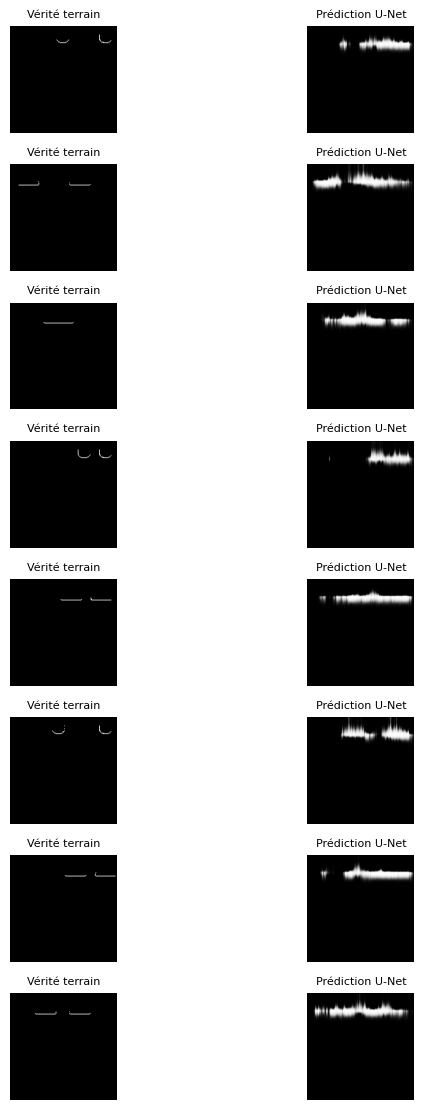

In [21]:
print("─── U-Net ───")
show_predictions(model_unet, test_loader, device,
                 num_samples=8,
                 threshold=results["U-Net"]["best_t"],
                 title="U-Net")

## 15) Diagnostic des erreurs (FP / FN)

─── Diagnostic U-Net ───


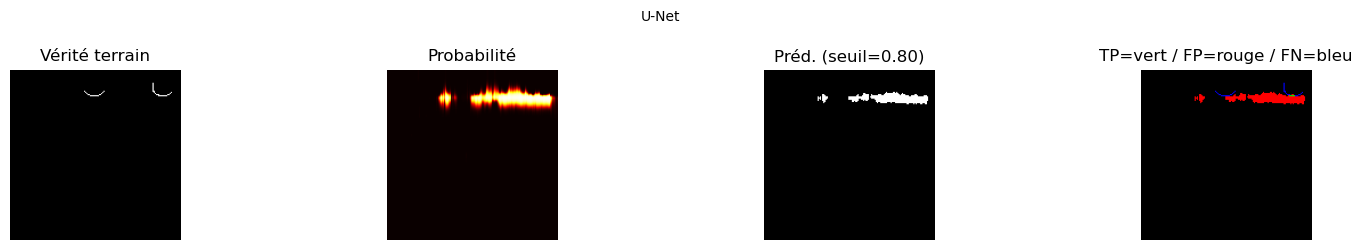

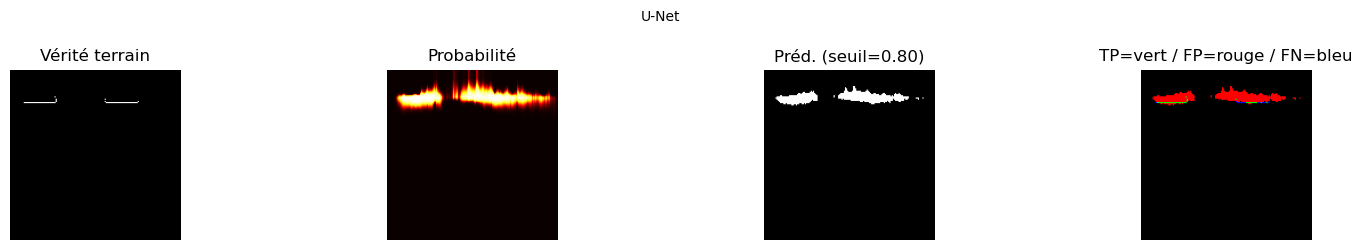

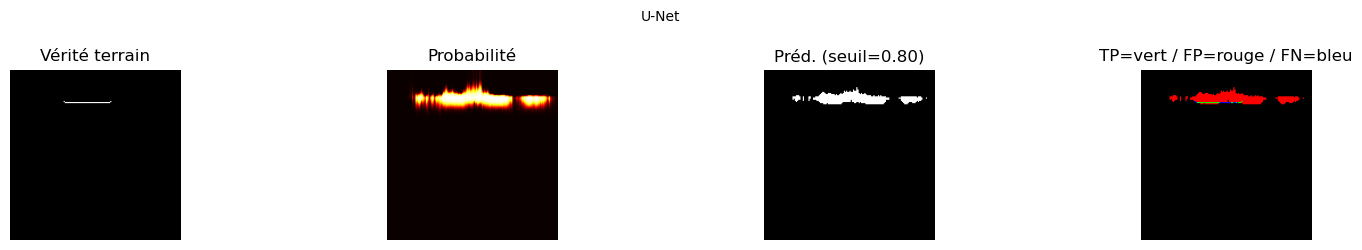

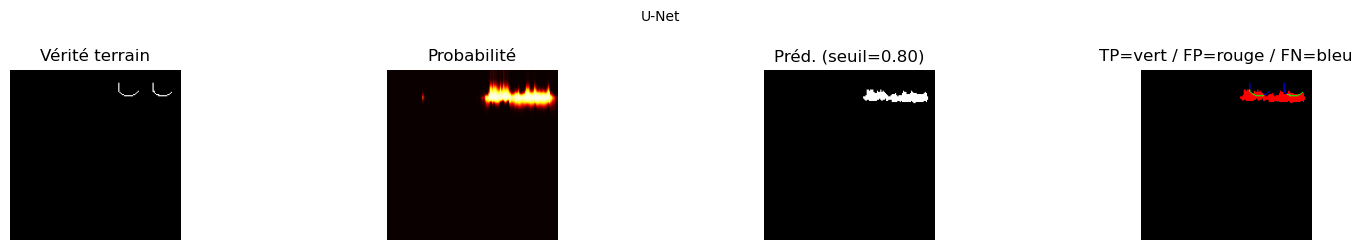

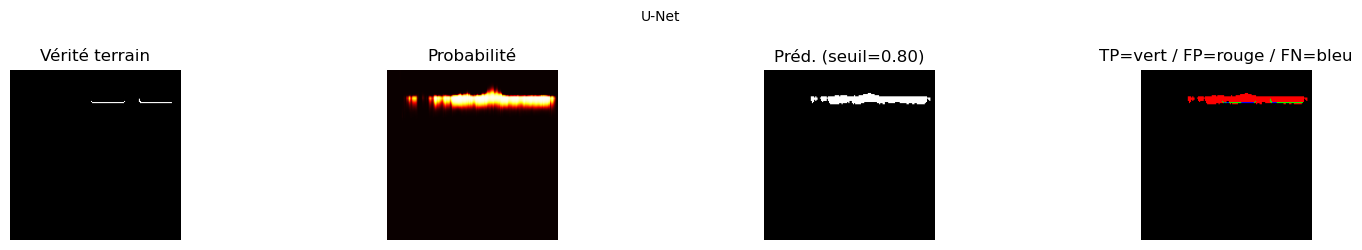

In [22]:
print("─── Diagnostic U-Net ───")
show_diagnostic(model_unet, test_loader, device,
                num_samples=5,
                threshold=results["U-Net"]["best_t"],
                title="U-Net")

## 16) Distribution des probabilités prédites

Un modèle qui fonctionne bien doit montrer une distribution **bimodale** :
beaucoup de valeurs proches de 0 (fond) et un pic vers 1 (objet).

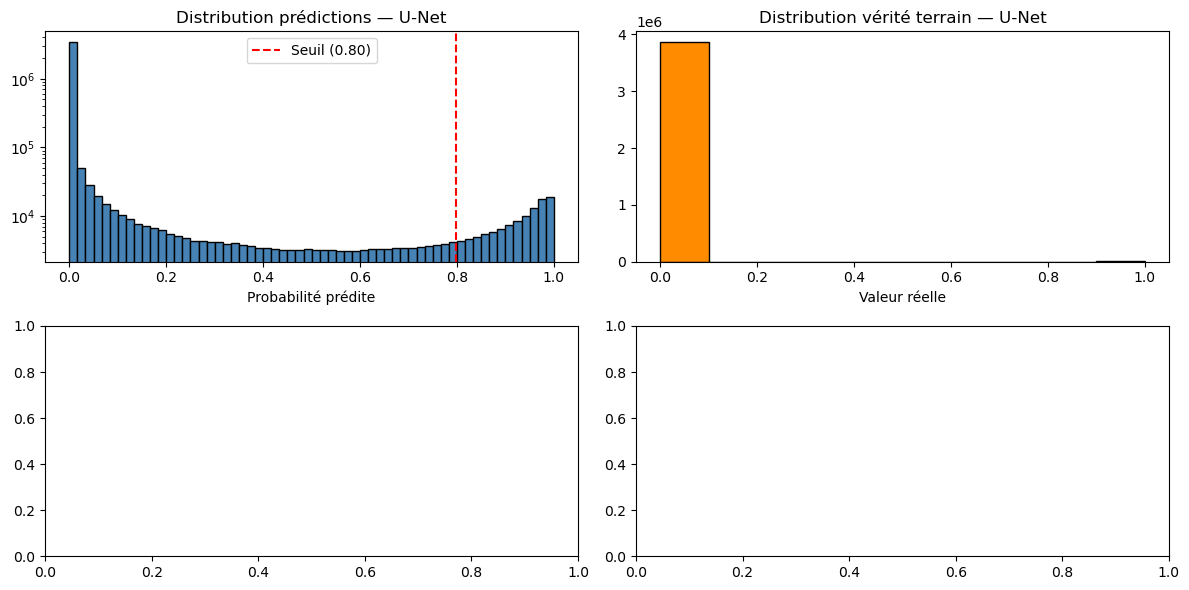

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for row, name in enumerate(["U-Net"]):
    r = results[name]

    axes[row, 0].hist(r['probs'], bins=60, color='steelblue', edgecolor='black', log=True)
    axes[row, 0].axvline(r['best_t'], color='red', linestyle='--', label=f"Seuil ({r['best_t']:.2f})")
    axes[row, 0].set_title(f"Distribution prédictions — {name}")
    axes[row, 0].set_xlabel("Probabilité prédite")
    axes[row, 0].legend()

    axes[row, 1].hist(r['targets'], bins=10, color='darkorange', edgecolor='black')
    axes[row, 1].set_title(f"Distribution vérité terrain — {name}")
    axes[row, 1].set_xlabel("Valeur réelle")

plt.tight_layout()
plt.show()

## 17) Tableau récapitulatif

## 18) Pipeline en cascade : UNet1D → Y-Net

Le Y-Net prend **deux entrées** :
- Les signaux bruts `(9, 801)` — Encodeur I
- La prédiction grossière du UNet1D `(1, 150, 150)` — Encodeur II

Le UNet1D est d'abord entraîné seul (étape précédente),
puis ses poids sont **figés** pendant l'entraînement du Y-Net.
Le Y-Net apprend uniquement à **affiner** la sortie du premier réseau.

```
Signaux (9,801) ──────────────────────────────────► Encodeur I ──┐
                 └──► UNet1D (figé) ──► carte grossière ──► Encodeur II ──┤
                                                                  └──► Décodeur ──► carte affinée
```


In [24]:
class DoubleConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class YNetCascade(nn.Module):
    """
    Y-Net prenant en entrée :
      - x_sig : signaux bruts (B, 9, 801)
      - x_coarse : prédiction grossière du UNet1D (B, 1, 150, 150)
    Retourne des logits (B, 1, 150, 150).
    """
    def __init__(self):
        super().__init__()

        # ── Encodeur I : signaux bruts 1D ─────────────────────────────────
        self.e1_1 = DoubleConv1D(9,  32)
        self.e1_2 = DoubleConv1D(32, 64)
        self.e1_3 = DoubleConv1D(64, 128)
        self.pool1 = nn.MaxPool1d(2)

        # ── Encodeur II : carte grossière 2D ──────────────────────────────
        self.e2_1 = DoubleConv2D(1,  32)
        self.e2_2 = DoubleConv2D(32, 64)
        self.e2_3 = DoubleConv2D(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # ── Décodeur partagé ──────────────────────────────────────────────
        # Chaque étage : upsample + skip enc2 + skip enc1 projeté en 2D
        self.up3  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv2D(64 + 64 + 64, 64)

        self.up2  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv2D(32 + 32 + 32, 32)

        self.up1  = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv2D(16, 16)

        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def _1d_to_2d(self, feat_1d, h, w):
        """Projette un skip 1D (B, C, L) en feature map 2D (B, C, H, W)."""
        # On broadcast sur la hauteur puis on interpole à la bonne taille
        x = feat_1d.unsqueeze(2).expand(-1, -1, h, -1)   # (B, C, H, L)
        return F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)

    def forward(self, x_sig, x_coarse):
        # ── Encodeur I ────────────────────────────────────────────────────
        s1_1 = self.e1_1(x_sig)                   # (B, 32,  801)
        s1_2 = self.e1_2(self.pool1(s1_1))        # (B, 64,  400)
        s1_3 = self.e1_3(self.pool1(s1_2))        # (B, 128, 200)

        # ── Encodeur II ───────────────────────────────────────────────────
        s2_1 = self.e2_1(x_coarse)                # (B, 32,  150, 150)
        s2_2 = self.e2_2(self.pool2(s2_1))        # (B, 64,   75,  75)
        s2_3 = self.e2_3(self.pool2(s2_2))        # (B, 128,  37,  37)

        # Goulot : on part de s2_3 (le plus compressé de l'enc II)
        d = self.up3(s2_3)                         # (B, 64, 75, 75)
        sk2 = F.interpolate(s2_2, d.shape[2:], mode='bilinear', align_corners=False)
        sk1 = self._1d_to_2d(s1_2, d.shape[2], d.shape[3])
        d = self.dec3(torch.cat([d, sk2, sk1], dim=1))

        d = self.up2(d)                            # (B, 32, 150, 150)
        sk2 = F.interpolate(s2_1, d.shape[2:], mode='bilinear', align_corners=False)
        sk1 = self._1d_to_2d(s1_1, d.shape[2], d.shape[3])
        d = self.dec2(torch.cat([d, sk2, sk1], dim=1))

        d = self.up1(d)
        d = self.dec1(d)
        out = self.final(d)
        return F.interpolate(out, size=(150, 150), mode='bilinear', align_corners=False)


# Vérification des shapes
with torch.no_grad():
    _sig    = torch.zeros(2, 9, 801)
    _coarse = torch.zeros(2, 1, 150, 150)
    print('YNetCascade output shape :', YNetCascade()(_sig, _coarse).shape)


YNetCascade output shape : torch.Size([2, 1, 150, 150])


### 18b) Dataset cascade

Le dataset cascade génère à la volée la prédiction grossière
du UNet1D (figé) pour alimenter l'Encodeur II du Y-Net.


In [25]:
class CascadeDataset(Dataset):
    """
    Dataset pour le Y-Net cascade.
    Utilise la reconstruction physique réelle (sub[1] du .mat)
    comme Encodeur II — plus besoin de la générer depuis le UNet1D.

    Retourne des triplets (x_sig, x_bf, y) :
      x_sig : signaux bruts    (9, 801)
      x_bf  : recons. physique (1, 150, 150)
      y     : carte cible      (1, 150, 150)
    """
    def __init__(self, sonar_dataset_with_bf):
        # On réutilise directement le SonarDataset qui contient X_bf
        self.ds = sonar_dataset_with_bf

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        # SonarDataset retourne (x, x_bf, y) quand X_bf est fourni
        return self.ds[idx]


# Loaders cascade — utilisent la reconstruction physique réelle
casc_train_loader = DataLoader(
    CascadeDataset(train_set), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
casc_val_loader = DataLoader(
    CascadeDataset(val_set), batch_size=BATCH_SIZE, shuffle=False
)
casc_test_loader = DataLoader(
    CascadeDataset(test_set), batch_size=BATCH_SIZE, shuffle=False
)
print('Loaders cascade créés (reconstruction physique réelle).')

# On n'a plus besoin de figer le UNet1D — le Y-Net utilise sub[1] directement
print('Note : le Y-Net utilise la reconstruction physique du fichier .mat')
print('       (sub[1]) comme second encodeur — aucun modèle à figer.')


Loaders cascade créés (reconstruction physique réelle).
Note : le Y-Net utilise la reconstruction physique du fichier .mat
       (sub[1]) comme second encodeur — aucun modèle à figer.


### 18c) Entraînement du Y-Net

La boucle d'entraînement est légèrement modifiée pour gérer
les **deux entrées** du Y-Net `(x_sig, x_coarse)`.


In [ ]:
def train_ynet(model, train_loader, val_loader, criterion, device,
               epochs=300, lr=5e-4, patience=40, model_name='ynet'):
    """
    Boucle d'entraînement pour le Y-Net en cascade.
    Les loaders fournissent des triplets (x_sig, x_coarse, y).
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=20
    )
    best_val   = float('inf')
    best_w     = copy.deepcopy(model.state_dict())
    no_improve = 0
    history    = {'train': [], 'val': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x_sig, x_coarse, y in train_loader:
            x_sig, x_coarse, y = x_sig.to(device), x_coarse.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_sig, x_coarse), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_sig, x_coarse, y in val_loader:
                x_sig, x_coarse, y = x_sig.to(device), x_coarse.to(device), y.to(device)
                val_loss += criterion(model(x_sig, x_coarse), y).item()
        val_loss /= len(val_loader)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'[{model_name}] Epoch {epoch+1:3d}/{epochs}  '
                  f'train={train_loss:.4f}  val={val_loss:.4f}')

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_w   = copy.deepcopy(model.state_dict())
            torch.save(best_w, f'{model_name}.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping à l\'epoch {epoch+1}')
                break

    model.load_state_dict(best_w)
    print(f'\n[{model_name}] Meilleure val_loss : {best_val:.4f}')
    return model, history


print('='*50)
print('Entraînement Y-Net cascade')
print('='*50)
model_ynet, history_ynet = train_ynet(
    YNetCascade(), casc_train_loader, casc_val_loader, criterion, device,
    epochs=300, lr=5e-4, patience=40, model_name='model_ynet_cascade'
)


In [26]:
def load_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Modèle chargé depuis {path}")
    return model
model_ynet = load_model(YNetCascade, "model_ynet_cascade.pth", device)

Modèle chargé depuis model_ynet_cascade.pth


### 18d) Évaluation du Y-Net cascade



Y-Net cascade — seuil optimal : 0.74
  Accuracy    : 1.0000
  Précision   : 0.9867
  Rappel      : 0.9958
  F1          : 0.9913
  IoU         : 0.9827


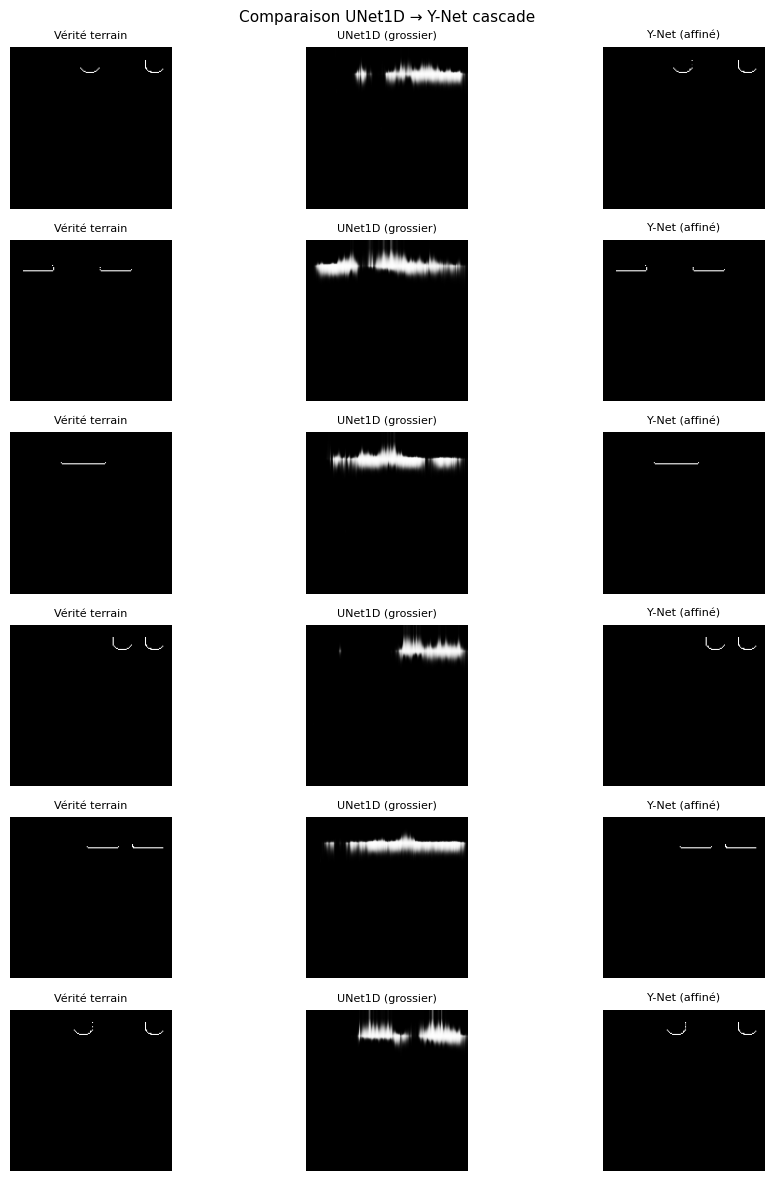

In [27]:
def collect_preds_ynet(model, loader, device):
    """Collecte prédictions pour le Y-Net (triplets en entrée)."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for x_sig, x_coarse, y in loader:
            x_sig, x_coarse = x_sig.to(device), x_coarse.to(device)
            probs = torch.sigmoid(model(x_sig, x_coarse)).cpu().numpy()
            all_probs.append(probs.flatten())
            all_targets.append(y.numpy().flatten())
    return np.concatenate(all_probs), np.concatenate(all_targets)


def show_cascade_comparison(model_base, model_ynet, loader_base,
                             loader_casc, device, num_samples=6,
                             threshold=0.5):
    """Affiche GT / UNet1D grossier / Y-Net affiné côte à côte."""
    model_base.eval()
    model_ynet.eval()
    shown = 0
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 2))

    base_iter = iter(loader_base)
    casc_iter = iter(loader_casc)

    while shown < num_samples:
        x_base, y_base = next(base_iter)
        x_sig, x_coarse, y_casc = next(casc_iter)

        with torch.no_grad():
            prob_base = torch.sigmoid(
                model_base(x_base.to(device))).cpu().numpy()
            prob_ynet = torch.sigmoid(
                model_ynet(x_sig.to(device), x_coarse.to(device))).cpu().numpy()

        for i in range(x_base.size(0)):
            if shown >= num_samples:
                break
            axes[shown, 0].imshow(y_base[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 0].set_title('Vérité terrain', fontsize=8)
            axes[shown, 0].axis('off')

            axes[shown, 1].imshow(prob_base[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 1].set_title('UNet1D (grossier)', fontsize=8)
            axes[shown, 1].axis('off')

            axes[shown, 2].imshow(prob_ynet[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 2].set_title('Y-Net (affiné)', fontsize=8)
            axes[shown, 2].axis('off')
            shown += 1

    plt.suptitle('Comparaison UNet1D → Y-Net cascade', fontsize=11)
    plt.tight_layout()
    plt.show()


# Métriques Y-Net
probs_yn, targets_yn = collect_preds_ynet(model_ynet, casc_test_loader, device)
thresholds = np.linspace(0.05, 0.95, 60)
f1s_yn = [compute_metrics(probs_yn, targets_yn, t)['F1'] for t in thresholds]
best_t_yn = thresholds[np.argmax(f1s_yn)]
metrics_yn = compute_metrics(probs_yn, targets_yn, best_t_yn)

print(f'\nY-Net cascade — seuil optimal : {best_t_yn:.2f}')
for k, v in metrics_yn.items():
    print(f'  {k:<12}: {v:.4f}')

# Comparaison visuelle
show_cascade_comparison(
    model_unet, model_ynet,
    test_loader, casc_test_loader,
    device, num_samples=6, threshold=best_t_yn
)


### 18e) Tableau comparatif final


In [28]:
# Tableau comparatif : SimpleCNN / UNet1D / Y-Net cascade
print(f'{'Métrique':<14} {'U-Net':>12} {'Y-Net':>12}')
print('-' * 52)
for metric in ['Accuracy', 'Précision', 'Rappel', 'F1', 'IoU']:
    v_unet = results['U-Net']['metrics'][metric]
    v_yn   = metrics_yn[metric]
    best = max(v_unet, v_yn)
    mark_unet = '  ←' if v_unet == best else ''
    mark_yn   = '  ←' if v_yn   == best else ''
    print(f'{metric:<14} '
          f'{v_unet:>12.4f}{mark_unet:<4} {v_yn:>12.4f}{mark_yn}')
print('-' * 52)
#print(f'{'Seuil opt.':<14} {results["best_t"]:>12.2f} '
      #f'{results["U-Net"]["best_t"]:>12.2f} {best_t_yn:>12.2f}')


Métrique              U-Net        Y-Net
----------------------------------------------------
Accuracy             0.9730           1.0000  ←
Précision            0.0529           0.9867  ←
Rappel               0.6997           0.9958  ←
F1                   0.0984           0.9913  ←
IoU                  0.0517           0.9827  ←
----------------------------------------------------



─── Diagnostic Y-Net cascade ───


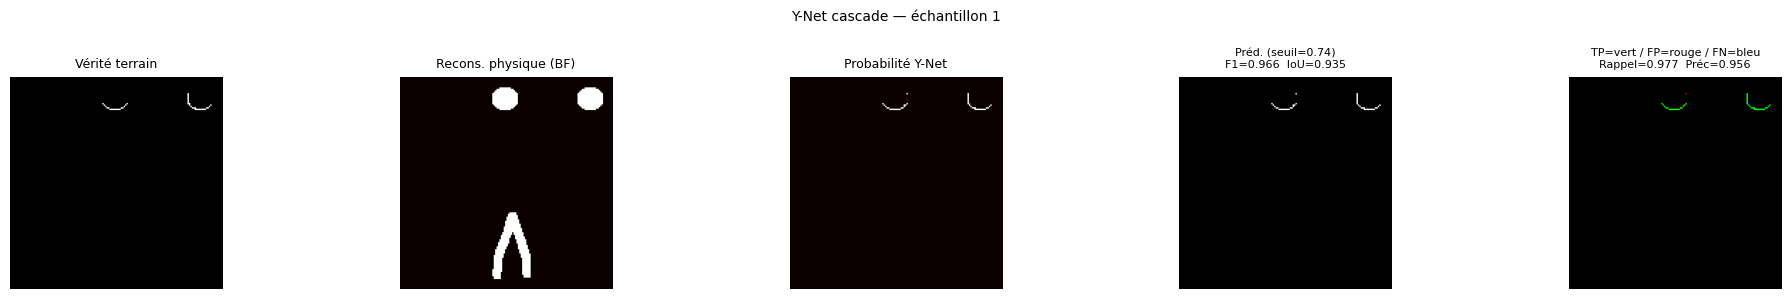

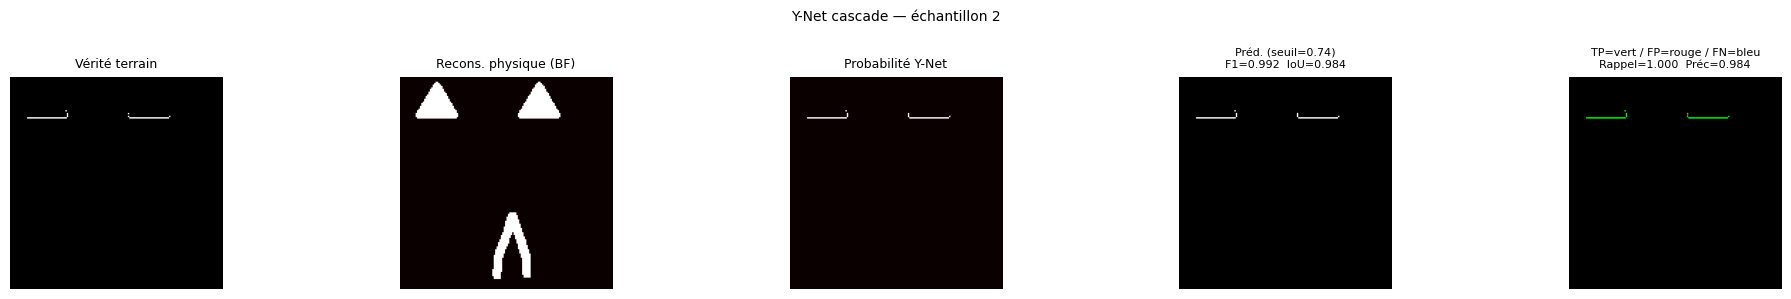

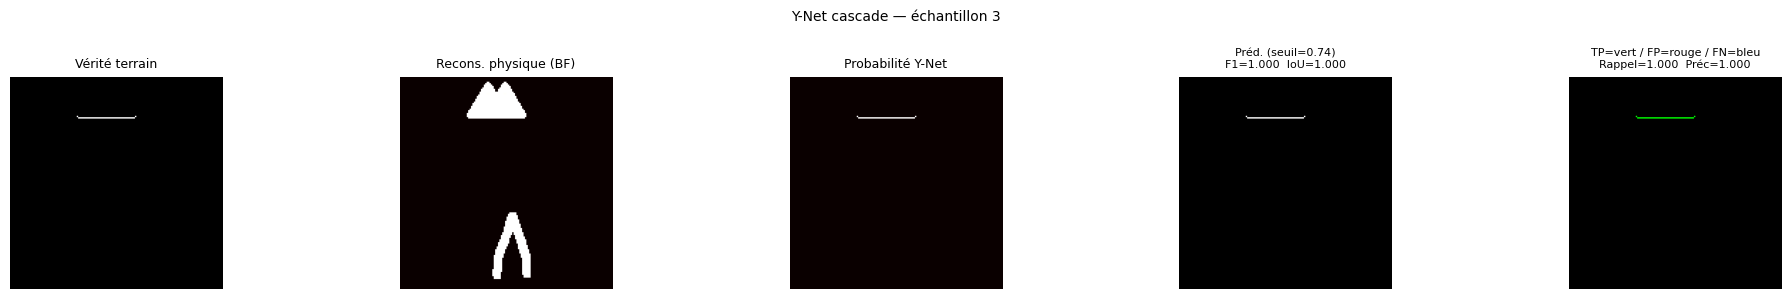

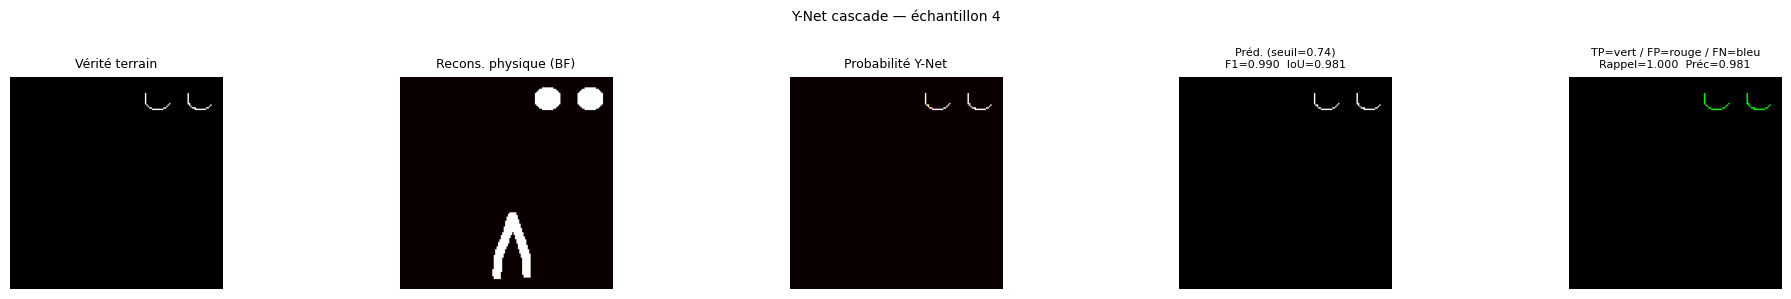

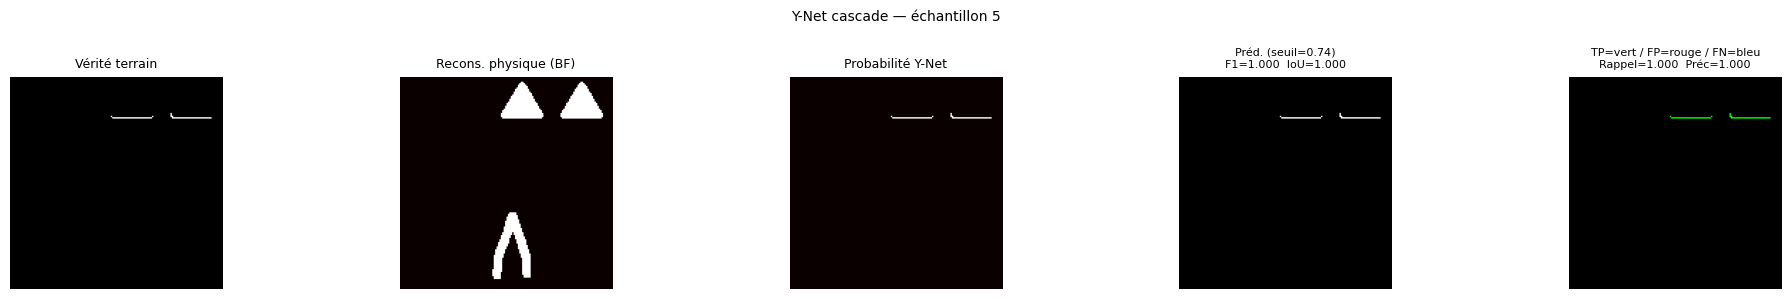

In [35]:
def show_diagnostic_ynet(model, loader, device, num_samples=5,
                          threshold=0.5, title='Y-Net'):
    """
    Diagnostic complet pour le Y-Net cascade.
    Affiche pour chaque exemple 5 colonnes :
      1. Vérité terrain
      2. Reconstruction physique (BF) — entrée Encodeur II
      3. Carte de probabilité prédite
      4. Prédiction binarisée
      5. Carte d'erreurs (TP=vert / FP=rouge / FN=bleu)
    """
    model.eval()
    shown = 0

    with torch.no_grad():
        for x_sig, x_coarse, y in loader:
            x_sig_d   = x_sig.to(device)
            x_coarse_d = x_coarse.to(device)
            probs = torch.sigmoid(model(x_sig_d, x_coarse_d)).cpu().numpy()

            for i in range(x_sig.size(0)):
                if shown >= num_samples:
                    return

                prob   = probs[i].squeeze()                   # (150, 150)
                pred   = (prob >= threshold).astype(float)
                target = y[i].squeeze().numpy()               # (150, 150)
                bf     = x_coarse[i].squeeze().numpy()        # (150, 150)

                # Carte d'erreurs RGB
                err = np.zeros((*target.shape, 3))
                err[(pred==1) & (target==1)] = [0, 1, 0]     # TP vert
                err[(pred==1) & (target==0)] = [1, 0, 0]     # FP rouge
                err[(pred==0) & (target==1)] = [0, 0, 1]     # FN bleu

                # Métriques par image
                m = compute_metrics(prob.flatten(), target.flatten(), threshold)

                fig, axes = plt.subplots(1, 5, figsize=(20, 3))

                axes[0].imshow(target, cmap='gray', vmin=0, vmax=1)
                axes[0].set_title('Vérité terrain', fontsize=9)

                axes[1].imshow(bf, cmap='hot', vmin=0, vmax=1)
                axes[1].set_title('Recons. physique (BF)', fontsize=9)

                axes[2].imshow(prob, cmap='hot', vmin=0, vmax=1)
                axes[2].set_title('Probabilité Y-Net', fontsize=9)

                axes[3].imshow(pred, cmap='gray', vmin=0, vmax=1)
                axes[3].set_title(
                    f'Préd. (seuil={threshold:.2f})\n'
                    f'F1={m["F1"]:.3f}  IoU={m["IoU"]:.3f}',
                    fontsize=8
                )

                axes[4].imshow(err)
                axes[4].set_title(
                    f'TP=vert / FP=rouge / FN=bleu\n'
                    f'Rappel={m["Rappel"]:.3f}  Préc={m["Précision"]:.3f}',
                    fontsize=8
                )

                for ax in axes:
                    ax.axis('off')

                fig.suptitle(f'{title} — échantillon {shown+1}', fontsize=10)
                plt.tight_layout()
                plt.show()
                shown += 1

# ── Diagnostic Y-Net ─────────────────────────────────────────────────────────
print('\n─── Diagnostic Y-Net cascade ───')
show_diagnostic_ynet(
    model_ynet, casc_test_loader, device,
    num_samples=5, threshold=best_t_yn, title='Y-Net cascade'
)